### Notebook to overlay qMSI and Stereo-seq sections
#### Tissues: IRI1, IRI2, IRI3

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import scanpy as sc
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from scipy.spatial import cKDTree

import warnings
warnings.filterwarnings("ignore")

banksy_output = "/exports/humgen/bmanzato/banksy_data"
qmsi_data = "/exports/humgen/bmanzato/nieromics_dir/qMSI_data"
lts = "/exports/archive/hg-funcgenom-research/IRI_multimodal_project/Stereo-seq_IRI"
nieromics_dir = "/exports/humgen/bmanzato/nieromics_dir"

#### Read qMSI

In [2]:
# Banksy result 
biri_sd_wgaps = pd.read_csv(f"{banksy_output}/output_data/bIRI_banksy_QMSI_RPCA_lambda1_kgeom8_res1_agftrue_scalefalse.csv",index_col=0)

# Coord bIRI
biri1_coord = pd.read_csv(f"{qmsi_data}/coord/20240720 mouse IRI kidney bIRI_1_xycoord.csv",index_col=0,comment='#',sep=";")
biri2_coord = pd.read_csv(f"{qmsi_data}/coord/20240720 mouse IRI kidney bIRI_2_xycoord.csv",index_col=0,comment='#',sep=";")
biri3_coord = pd.read_csv(f"{qmsi_data}/coord/20240720 mouse IRI kidney bIRI_3_xycoord.csv",index_col=0,comment='#',sep=";")
biri_coord = pd.concat([biri1_coord,biri2_coord,biri3_coord],axis=0)

# Add coordinates to Banksy result df 
biri_coord.index = biri_sd_wgaps.index
biri_sd_wgaps[['x','y']] = biri_coord[['x','y']]

biri_sd_wogaps = pd.read_csv(f"{banksy_output}/output_data/bIRI_banksy_QMSI_RPCA_lambda1_kgeom8_res1_agftrue_scalefalse_130lipids_NOgaps.csv",index_col=0)
biri_sd = biri_sd_wgaps[biri_sd_wgaps.index.isin(biri_sd_wogaps.index)]
biri_sd['clust_M1_lam1_k50_res1'] = biri_sd_wogaps['clust_M1_lam1_k50_res1']

# rPCA count matrix
rpca_df = pd.read_csv(f"{qmsi_data}/rpca_df.csv",index_col=0)
# separate biri and sham
rpca_biri = rpca_df.iloc[:len(biri_coord), :]

### Read Stereo-seq

In [3]:
# read Banksy results
result_biri = pd.read_csv(f"{banksy_output}/output_data/df_biri.csv",index_col=0)
result_sham = pd.read_csv(f"{banksy_output}/output_data/df_sham.csv",index_col=0)

ad_obj = ad.read_h5ad(f"{lts}/post-integration-obj/allkidneys_sct.h5ad")

# read the new annotations (from 3rd of July)
barcode_ann = pd.read_csv(f"{lts}/barcode_annotation.csv",index_col=0)

barcode_ann['_group'] = barcode_ann.index.str[-1]

# Create two separate DataFrames based on the grouping
sham_ann = barcode_ann[barcode_ann['_group'].isin(['1', '2', '3'])].copy()
biri_ann = barcode_ann[barcode_ann['_group'].isin(['4', '5', '6'])].copy()

biri_ann.drop('_group', axis=1, inplace=True)
sham_ann.drop('_group', axis=1, inplace=True)

biri_ann.index = biri_ann.index.str[:-2]
sham_ann.index = sham_ann.index.str[:-2]

biri_ann.index = biri_ann.index+'_biri'
sham_ann.index = sham_ann.index+'_sham'

ann = pd.concat([biri_ann,sham_ann],axis=0)

# add them to the h5ad object
ad_obj.obs['new_CT_annotation'] = ann['x']

# Subset data to only have either IRI or sham (since they are same coordinate space)
ad_obj_biri = ad_obj[ad_obj.obs['kidney_n'].str.startswith('bIRI')]
ad_obj_sham = ad_obj[ad_obj.obs['kidney_n'].str.startswith('Sham')]

ad_obj_biri.obs.index = ad_obj_biri.obs.index.astype(str).str[:-5]
ad_obj_sham.obs.index = ad_obj_sham.obs.index.astype(str).str[:-5]

# filter
ad_obj_biri = ad_obj_biri[ad_obj_biri.obs.index.isin(result_biri.index)]
ad_obj_sham = ad_obj_sham[ad_obj_sham.obs.index.isin(result_sham.index)]

# rename index and column
result_biri.index = ad_obj_biri.obs.index
ad_obj_biri.obs['banksy_l1_k8_res1'] = result_biri['clust_M1_lam1_k50_res1']

result_sham.index = ad_obj_sham.obs.index
ad_obj_sham.obs['banksy_l1_k8_res1'] = result_sham['clust_M1_lam1_k50_res1']

# QC filter

ad_obj_biri = ad_obj_biri[ad_obj_biri.obs['percent.mt']<10]
ad_obj_biri = ad_obj_biri[(ad_obj_biri.obs['nFeature_RNA']>200) & (ad_obj_biri.obs['nFeature_RNA']<2500)]

ad_obj_sham = ad_obj_sham[ad_obj_sham.obs['percent.mt']<10]
ad_obj_sham = ad_obj_sham[(ad_obj_sham.obs['nFeature_RNA']>200) & (ad_obj_sham.obs['nFeature_RNA']<2500)]

#### Subset to keep only bIRI1

In [4]:
biri_ss = ad_obj_biri.obs[ad_obj_biri.obs.kidney_n == 'bIRI1']
biri_qmsi = biri_sd[biri_sd['kidney'] == 'biri1']

##### Scatterplot raw coordinates

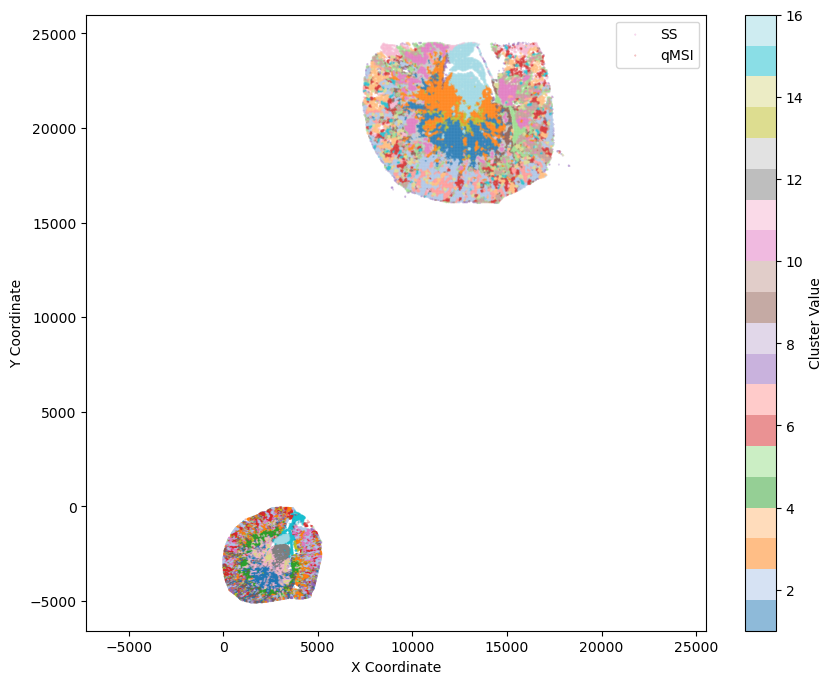

In [5]:
def plot_scatter(df1, df2):
    plt.figure(figsize=(10, 8))

    cmap = get_cmap('tab20')

    scatter1 = plt.scatter(df1['x'], df1['y'], c=df1['banksy_l1_k8_res1'], cmap=cmap, label='SS', alpha=0.5, s=0.1)
    scatter2 = plt.scatter(df2['x'], df2['y'], c=df2['clust_M1_lam1_k50_res1'], cmap=cmap, label='qMSI', alpha=0.5, s=0.1)

    plt.colorbar(scatter2, label='Cluster Value')

    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.axis('equal') 

    plt.show()

plot_scatter(biri_ss, biri_qmsi)

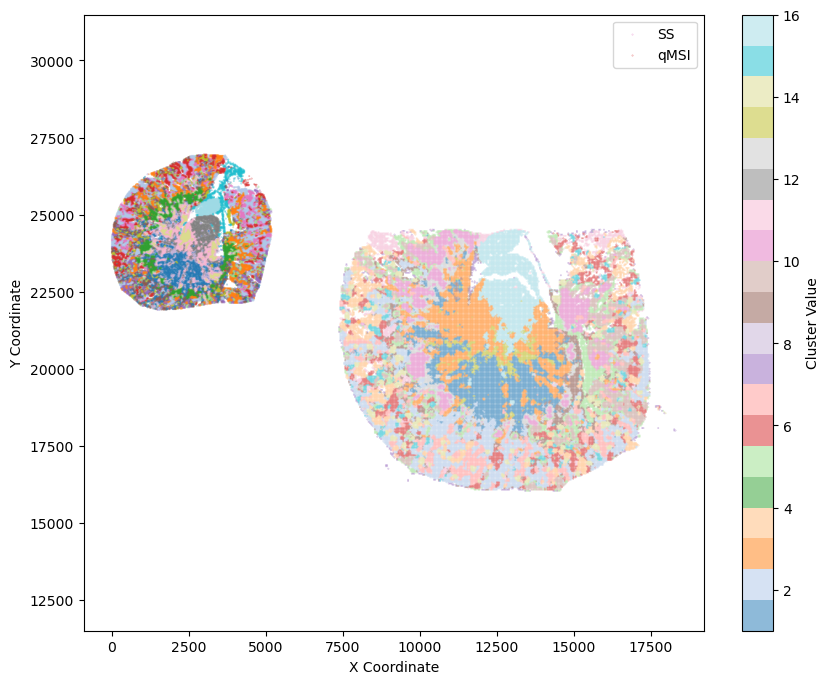

In [6]:
# translate x and y
biri_qmsi['y'] =  biri_qmsi['y']+27000
plot_scatter(biri_ss, biri_qmsi)

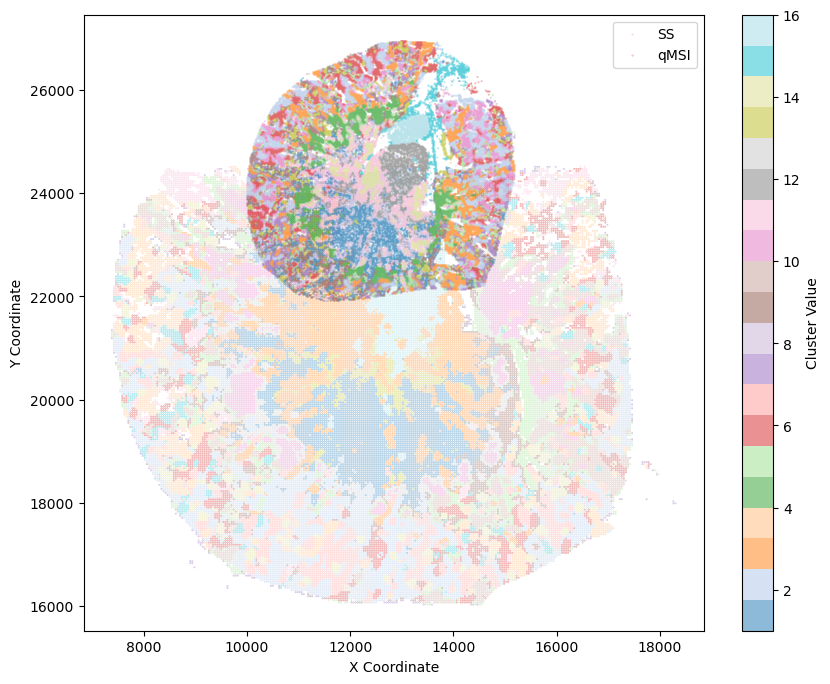

In [7]:
biri_qmsi['x'] =  biri_qmsi['x']+10000
plot_scatter(biri_ss, biri_qmsi)

In [8]:
# Function to rotate coordinates counterclockwise around the centroid
def rotate_coordinates(df, angle_degrees):
    # Calculate the centroid (mean of x and y)
    centroid_x = df['x'].mean()
    centroid_y = df['y'].mean()

    angle_radians = np.radians(angle_degrees)

    rotation_matrix = np.array([
        [np.cos(angle_radians), -np.sin(angle_radians)],
        [np.sin(angle_radians), np.cos(angle_radians)]
    ])

    shifted_coords = df[['x', 'y']].values - [centroid_x, centroid_y]

    rotated_coords = np.dot(shifted_coords, rotation_matrix.T)

    rotated_coords += [centroid_x, centroid_y]

    df['x'] = rotated_coords[:, 0]
    df['y'] = rotated_coords[:, 1]

    return df

df_rotated = rotate_coordinates(biri_qmsi, 20)

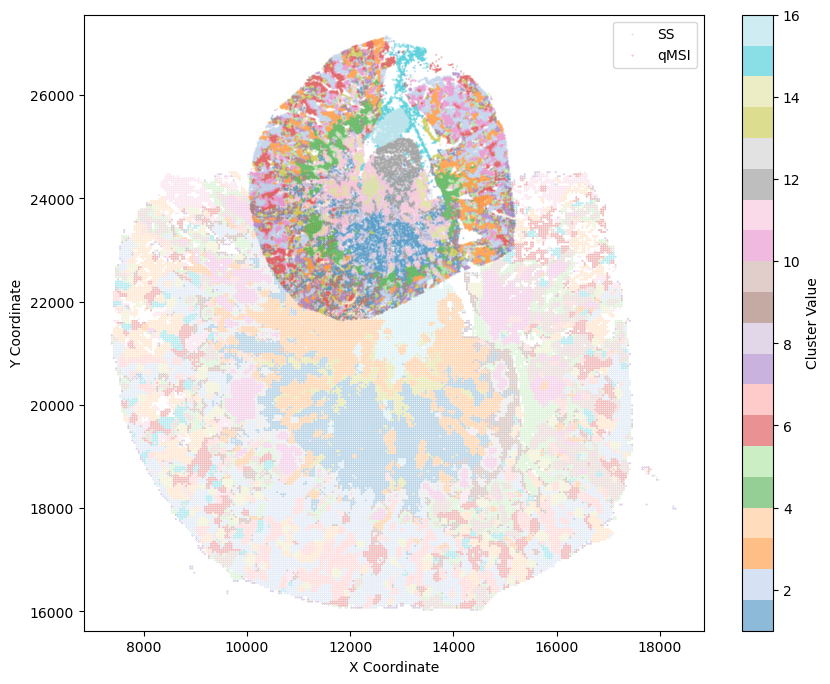

In [9]:
plot_scatter(biri_ss, df_rotated)

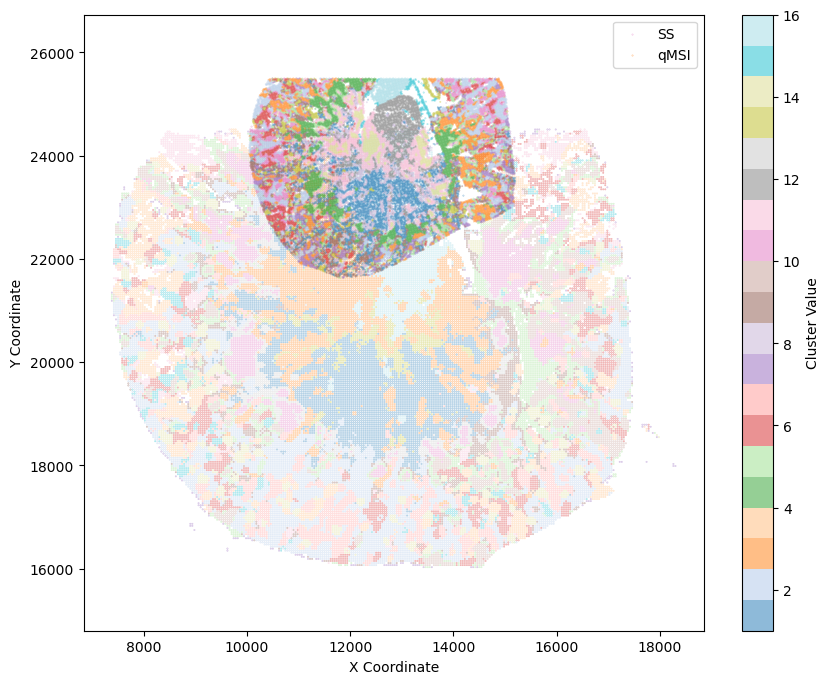

In [10]:
# remove spots y>25500 because stereo-seq is missing portion of the tissue
df_rotated = df_rotated[df_rotated['y']<25500]
plot_scatter(biri_ss, df_rotated)

In [11]:
def rescale_coordinates(df1, df2):
    x_min_df2, x_max_df2 = df2['x'].min(), df2['x'].max()
    y_min_df2, y_max_df2 = df2['y'].min(), df2['y'].max()

    x_min_df1, x_max_df1 = df1['x'].min(), df1['x'].max()
    y_min_df1, y_max_df1 = df1['y'].min(), df1['y'].max()

    df1['x'] = (df1['x'] - x_min_df1) / (x_max_df1 - x_min_df1) * (x_max_df2 - x_min_df2) + x_min_df2
    df1['y'] = (df1['y'] - y_min_df1) / (y_max_df1 - y_min_df1) * (y_max_df2 - y_min_df2) + y_min_df2

    return df1

In [12]:
qmsi_rescaled = rescale_coordinates(df_rotated, biri_ss)

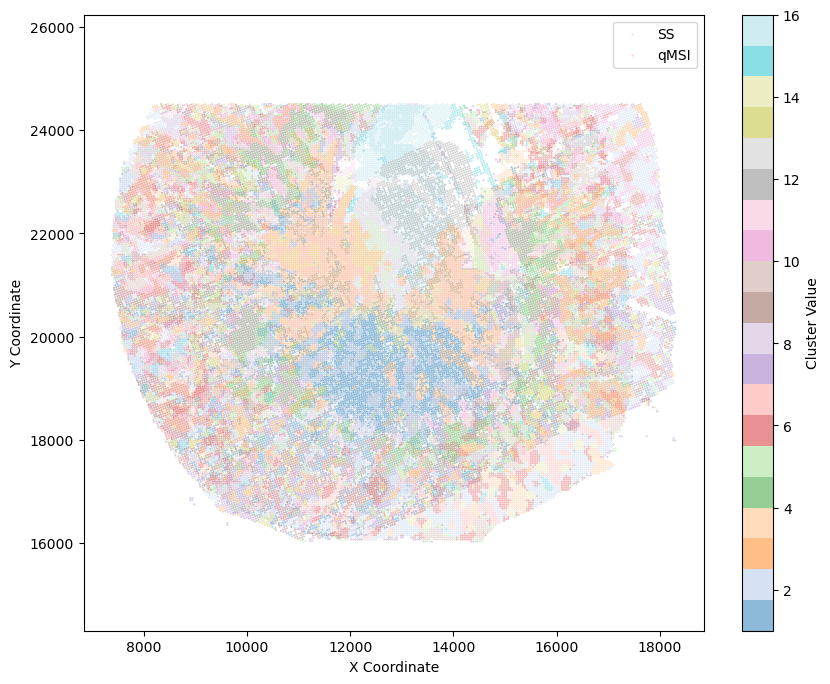

In [13]:
plot_scatter(biri_ss, qmsi_rescaled)

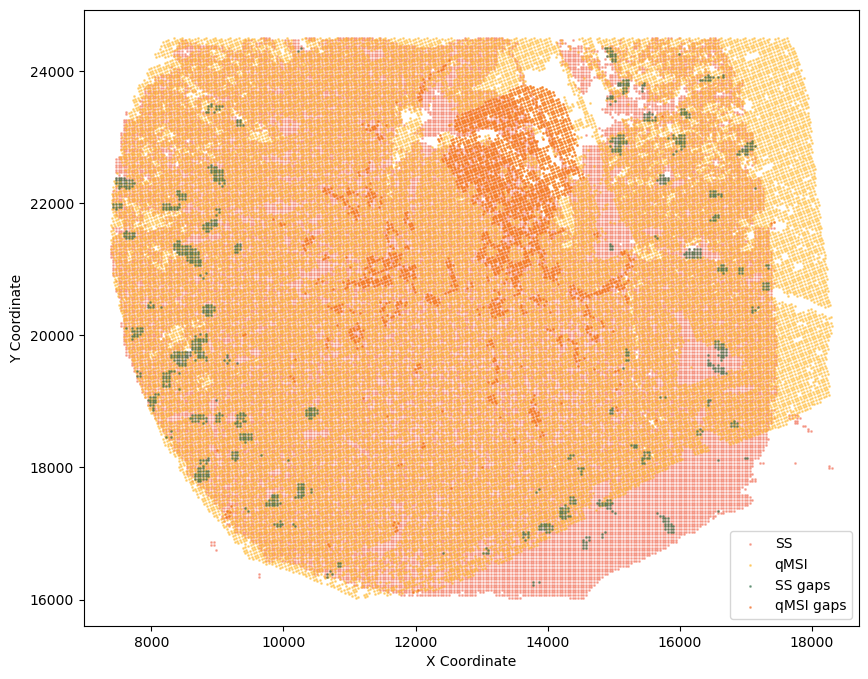

In [14]:
# color by GAPS SD
biri_qmsi_gaps = df_rotated[df_rotated['clust_M1_lam1_k50_res1'] == 12]
biri_ss_gaps = biri_ss[biri_ss['banksy_l1_k8_res1'] == 16]

def plot_gaps(df1, df2):
    plt.figure(figsize=(10, 8))

    plt.scatter(df1['x'], df1['y'], color='#f27059', label='SS', alpha=0.5, s=1)
    plt.scatter(df2['x'], df2['y'], color='#ffb627', label='qMSI', alpha=0.5, s=1)

    plt.scatter(biri_ss_gaps['x'], biri_ss_gaps['y'], color='#2c6e49', label='SS gaps', alpha=0.5, s=1)
    plt.scatter(biri_qmsi_gaps['x'], biri_qmsi_gaps['y'], color='#f26419', label='qMSI gaps', alpha=0.5, s=1)

    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend(loc='best')  
    plt.axis('equal') 

    plt.show()

plot_gaps(biri_ss, qmsi_rescaled)

In [15]:
qmsi_rescaled['x'] = qmsi_rescaled['x']-400 # move x 

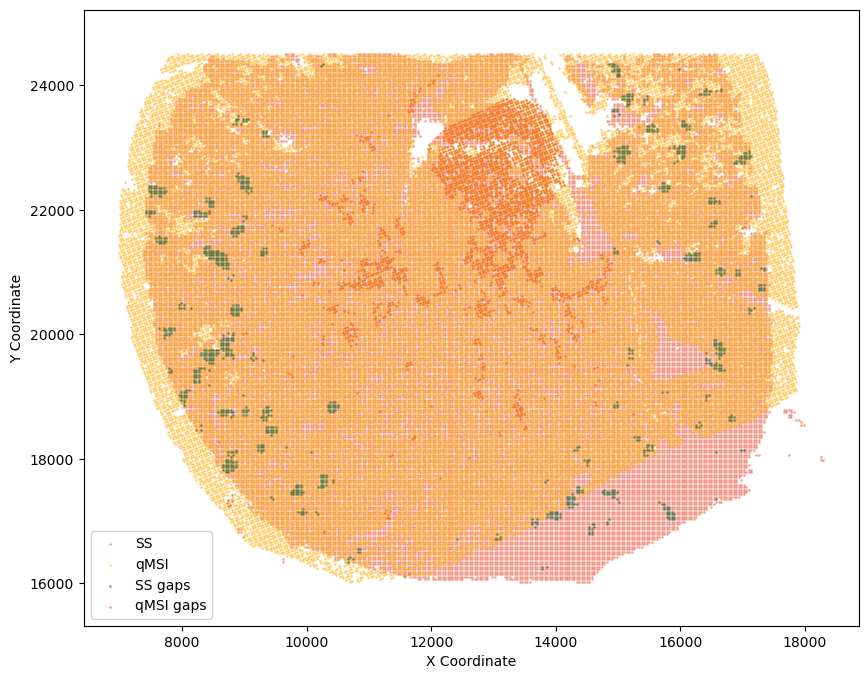

In [16]:
biri_qmsi_gaps = qmsi_rescaled[qmsi_rescaled['clust_M1_lam1_k50_res1'] == 12]
biri_ss_gaps = biri_ss[biri_ss['banksy_l1_k8_res1'] == 16]
plot_gaps(biri_ss, qmsi_rescaled)

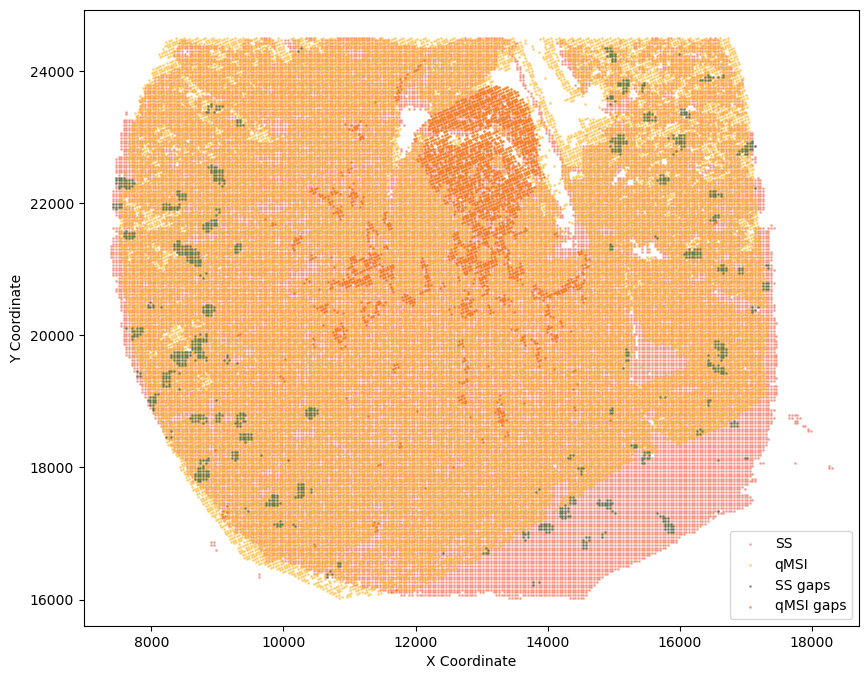

In [17]:
# shrink x by 0.9
x_center = qmsi_rescaled['x'].mean()

qmsi_rescaled['x'] = x_center + 0.9 * (qmsi_rescaled['x'] - x_center)

biri_qmsi_gaps = qmsi_rescaled[qmsi_rescaled['clust_M1_lam1_k50_res1'] == 12]
biri_ss_gaps = biri_ss[biri_ss['banksy_l1_k8_res1'] == 16]
plot_gaps(biri_ss, qmsi_rescaled)

In [18]:
#qmsi_rescaled.to_csv('qmsi_transformed_biri1.csv')

#### Subset to keep only bIRI2

In [19]:
biri_ss = ad_obj_biri.obs[ad_obj_biri.obs.kidney_n == 'bIRI2']
biri_qmsi = biri_sd[biri_sd['kidney'] == 'biri3']

##### Scatterplot before

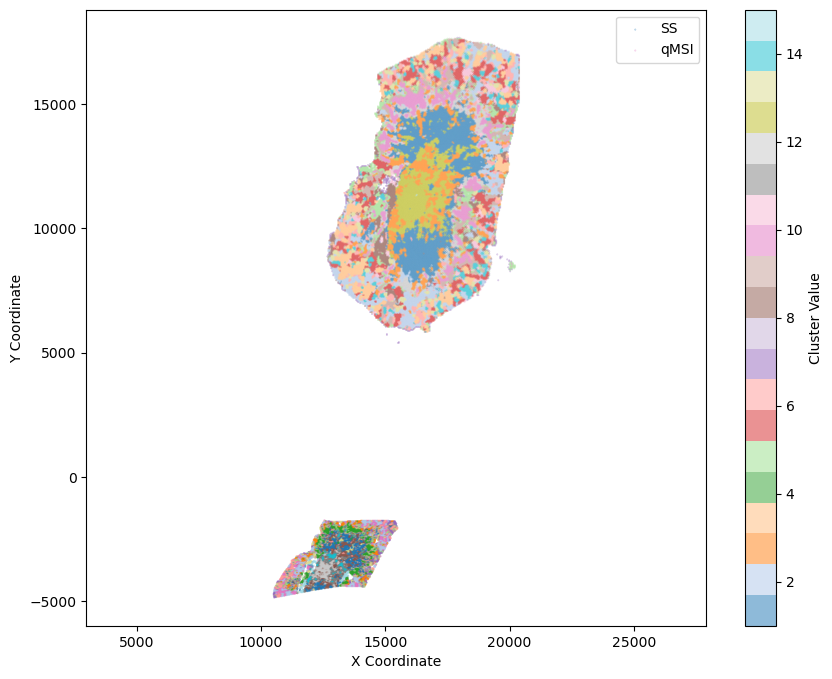

In [20]:
plot_scatter(biri_ss, biri_qmsi)

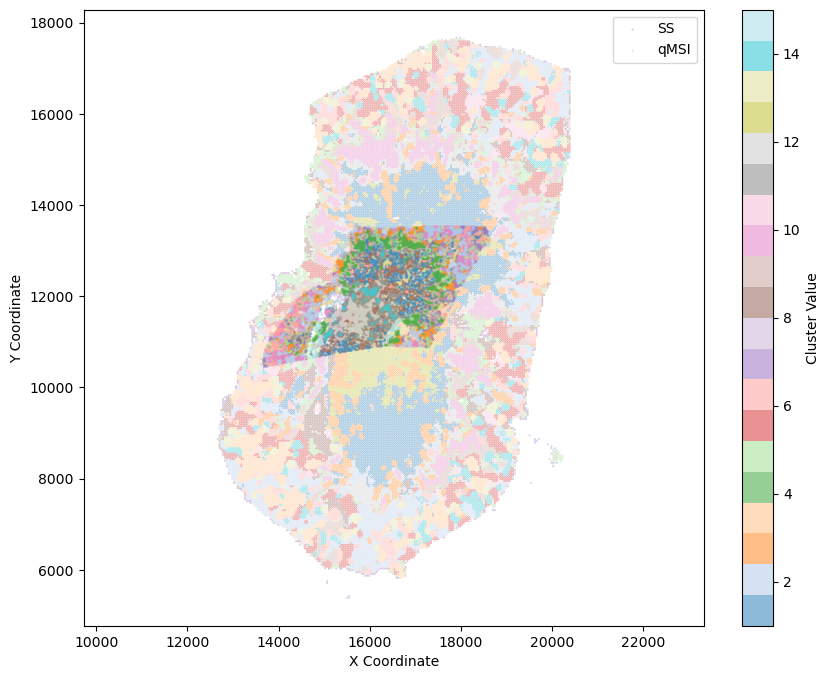

In [21]:
# translate x and y
biri_qmsi['y'] =  biri_qmsi['y']+15300
biri_qmsi['x'] =  biri_qmsi['x']+3150
plot_scatter(biri_ss, biri_qmsi)

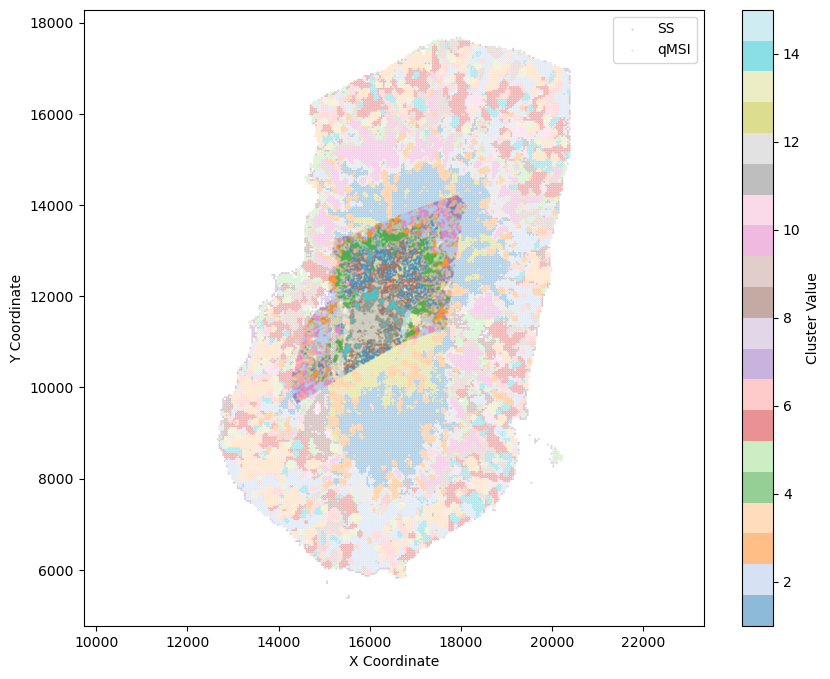

In [22]:
# rotate counterclockwise 20 degrees
df_rotated = rotate_coordinates(biri_qmsi, 20)
plot_scatter(biri_ss, df_rotated)

In [23]:
# rescale x only
def rescale_xcoordinates(df1, df2):
    x_min_df2, x_max_df2 = df2['x'].min(), df2['x'].max()
    x_min_df1, x_max_df1 = df1['x'].min(), df1['x'].max()

    df1['x'] = (df1['x'] - x_min_df1) / (x_max_df1 - x_min_df1) * (x_max_df2 - x_min_df2) + x_min_df2

    return df1

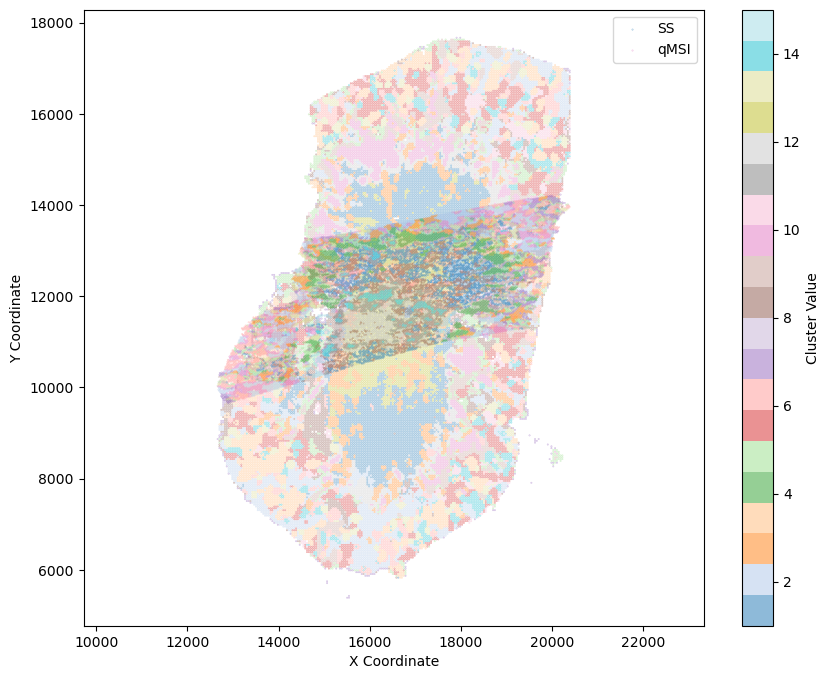

In [24]:
qmsi_rescaled = rescale_xcoordinates(df_rotated, biri_ss)
plot_scatter(biri_ss, qmsi_rescaled)

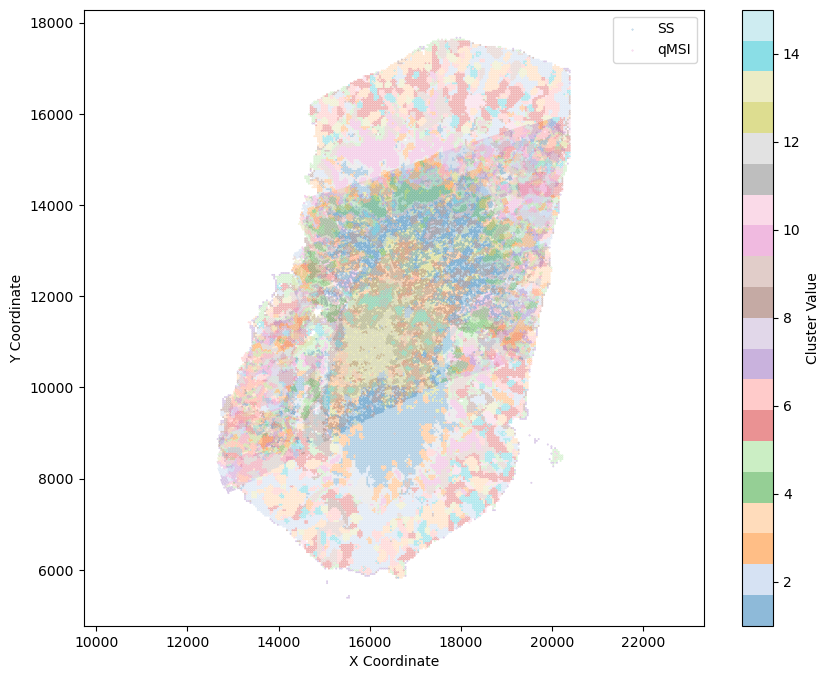

In [25]:
# rescale y by 1.5
x_center = qmsi_rescaled['y'].mean()
qmsi_rescaled['y'] = x_center + 1.8 * (qmsi_rescaled['y'] - x_center)

plot_scatter(biri_ss, qmsi_rescaled)

In [26]:
# translate y and x again
qmsi_rescaled['y'] =  qmsi_rescaled['y']+800
qmsi_rescaled['x'] =  qmsi_rescaled['x']+300

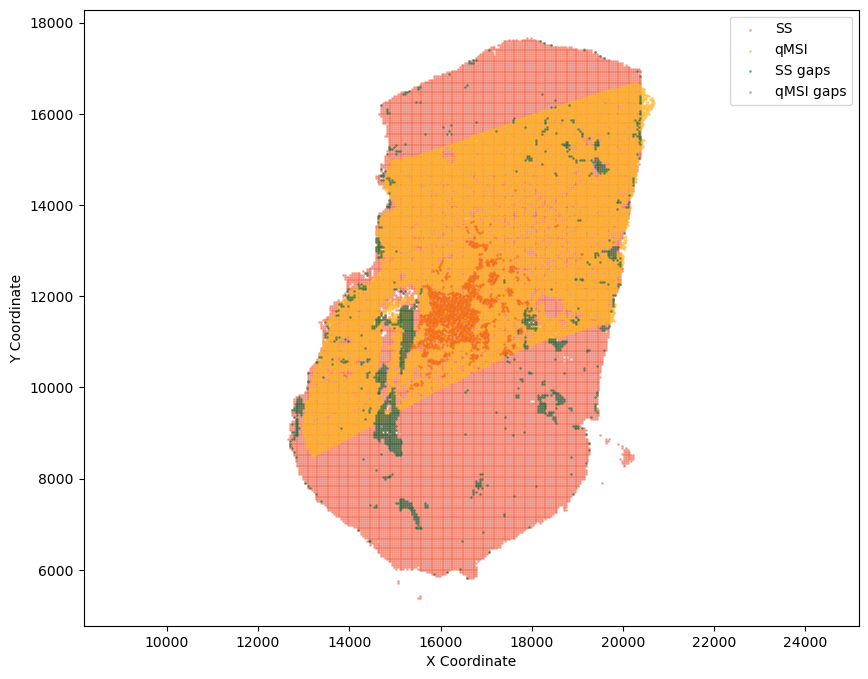

In [27]:
### plot GAPS SD
biri_qmsi_gaps = qmsi_rescaled[qmsi_rescaled['clust_M1_lam1_k50_res1'] == 12]
biri_ss_gaps = biri_ss[biri_ss['banksy_l1_k8_res1'] == 9]

plot_gaps(biri_ss, qmsi_rescaled)

In [28]:
qmsi_rescaled.to_csv('qmsi_transformed_biri2.csv')

#### Subset to keep only bIRI2

In [29]:
biri_ss = ad_obj_biri.obs[ad_obj_biri.obs.kidney_n == 'bIRI3']
biri_qmsi = biri_sd[biri_sd['kidney'] == 'biri2']

##### Scatterplot before

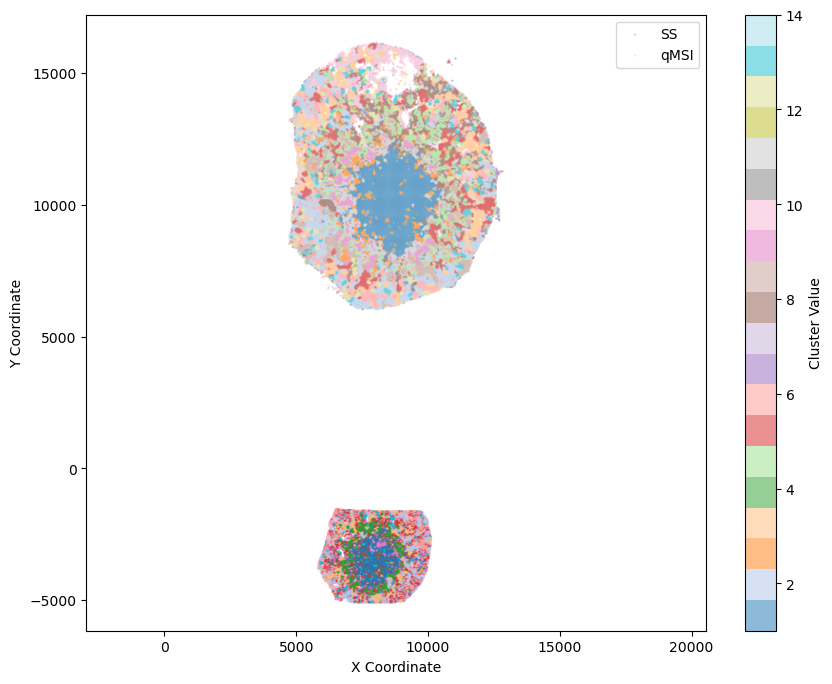

In [30]:
plot_scatter(biri_ss, biri_qmsi)

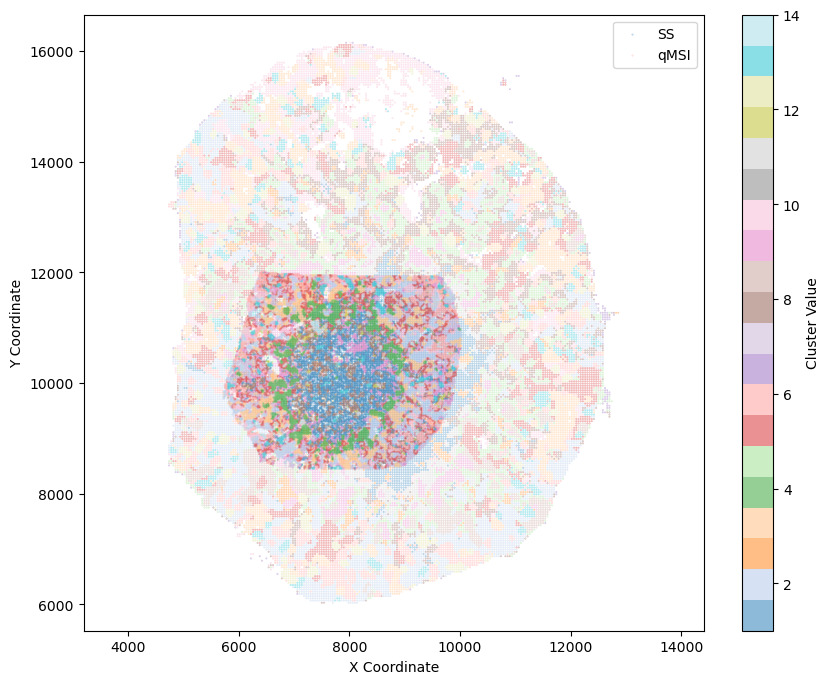

In [31]:
# translate x and y
biri_qmsi['y'] =  biri_qmsi['y']+13550
biri_qmsi['x'] =  biri_qmsi['x']-100
plot_scatter(biri_ss, biri_qmsi)

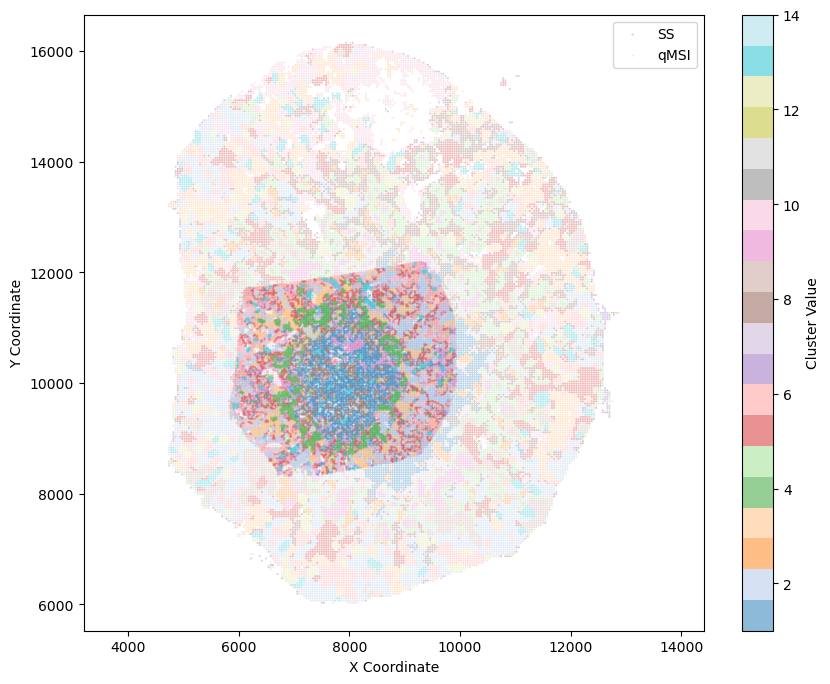

In [32]:
# rotate counterclockwise 10 degrees
df_rotated = rotate_coordinates(biri_qmsi, 10)
plot_scatter(biri_ss, df_rotated)

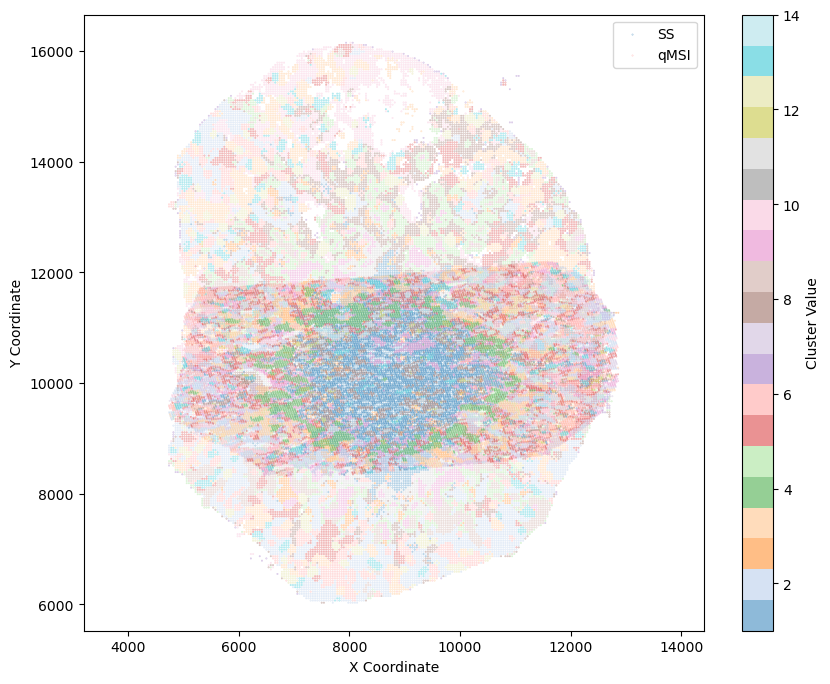

In [33]:
qmsi_rescaled = rescale_xcoordinates(biri_qmsi, biri_ss)
plot_scatter(biri_ss, qmsi_rescaled)

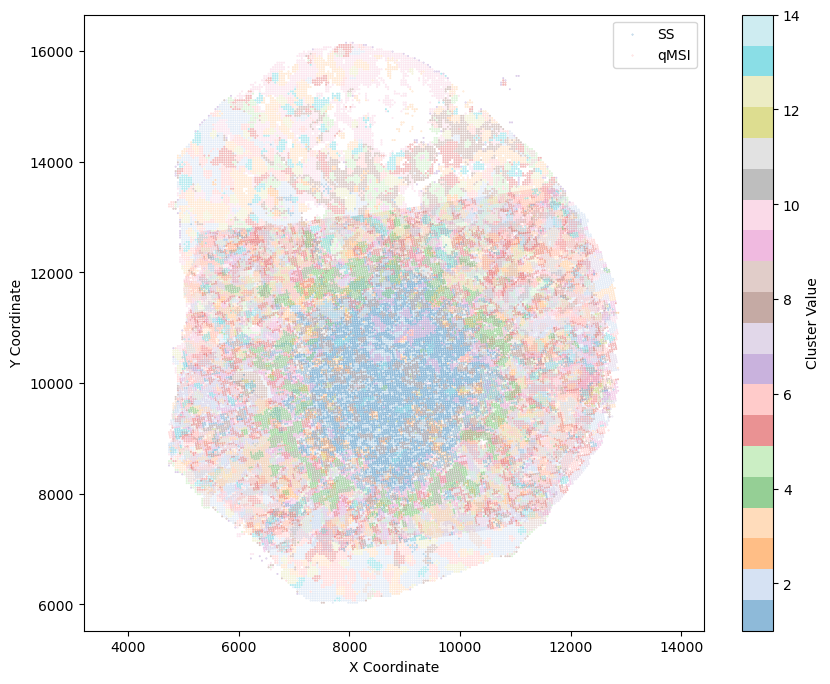

In [34]:
# rescale y by 1.8
x_center = qmsi_rescaled['y'].mean()
qmsi_rescaled['y'] = x_center + 1.7 * (qmsi_rescaled['y'] - x_center)

plot_scatter(biri_ss, qmsi_rescaled)

In [35]:
# translate x
qmsi_rescaled['x'] = qmsi_rescaled['x']-100

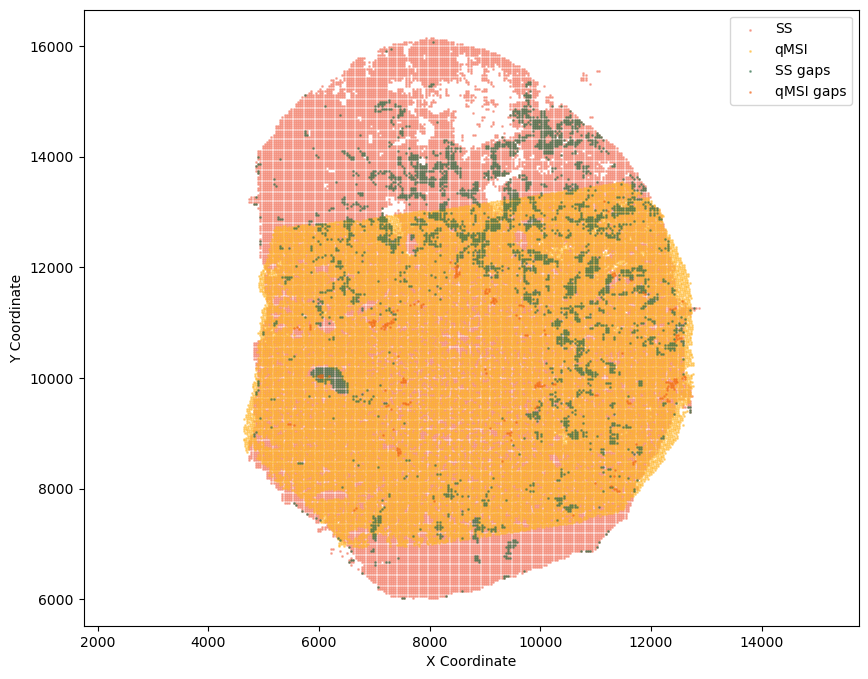

In [36]:
### plot GAPS SD
biri_qmsi_gaps = qmsi_rescaled[qmsi_rescaled['clust_M1_lam1_k50_res1'] == 12]
biri_ss_gaps = biri_ss[biri_ss['banksy_l1_k8_res1'] == 9]

plot_gaps(biri_ss, qmsi_rescaled)

In [37]:
qmsi_rescaled.to_csv('qmsi_transformed_biri3.csv')